In [53]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, recall_score, classification_report
from sklearn.tree import plot_tree, export_graphviz
import dtreeviz
import graphviz.backend as be
import matplotlib.pyplot as plt
from IPython.display import Image, display_svg, SVG

In [2]:
X_df, y_df = load_breast_cancer(as_frame=True, return_X_y=True)

In [3]:
sample = X_df.sample(10)
idx = sample.index
sample

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
402,12.96,18.29,84.18,525.2,0.07351,0.07899,0.040570,0.018830,0.1874,0.05899,...,14.13,24.61,96.31,621.9,0.09329,0.23180,0.16040,0.06608,0.3207,0.07247
144,10.75,14.97,68.26,355.3,0.07793,0.05139,0.022510,0.007875,0.1399,0.05688,...,11.95,20.72,77.79,441.2,0.10760,0.12230,0.09755,0.03413,0.2300,0.06769
179,12.81,13.06,81.29,508.8,0.08739,0.03774,0.009193,0.013300,0.1466,0.06133,...,13.63,16.15,86.70,570.7,0.11620,0.05445,0.02758,0.03990,0.1783,0.07319
386,12.21,14.09,78.78,462.0,0.08108,0.07823,0.068390,0.025340,0.1646,0.06154,...,13.13,19.29,87.65,529.9,0.10260,0.24310,0.30760,0.09140,0.2677,0.08824
450,11.87,21.54,76.83,432.0,0.06613,0.10640,0.087770,0.023860,0.1349,0.06612,...,12.79,28.18,83.51,507.2,0.09457,0.33990,0.32180,0.08750,0.2305,0.09952
526,13.46,18.75,87.44,551.1,0.10750,0.11380,0.042010,0.031520,0.1723,0.06317,...,15.35,25.16,101.90,719.8,0.16240,0.31240,0.26540,0.14270,0.3518,0.08665
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.052630,0.027880,0.1619,0.06408,...,11.62,26.51,76.43,407.5,0.14280,0.25100,0.21230,0.09861,0.2289,0.08278
492,18.01,20.56,118.40,1007.0,0.10010,0.12890,0.117000,0.077620,0.2116,0.06077,...,21.53,26.06,143.40,1426.0,0.13090,0.23270,0.25440,0.14890,0.3251,0.07625
466,13.14,20.74,85.98,536.9,0.08675,0.10890,0.108500,0.035100,0.1562,0.06020,...,14.80,25.46,100.90,689.1,0.13510,0.35490,0.45040,0.11810,0.2563,0.08174
18,19.81,22.15,130.00,1260.0,0.09831,0.10270,0.147900,0.094980,0.1582,0.05395,...,27.32,30.88,186.80,2398.0,0.15120,0.31500,0.53720,0.23880,0.2768,0.07615


In [4]:
y_df[idx]

402    1
144    1
179    1
386    1
450    1
526    1
534    1
492    0
466    1
18     0
Name: target, dtype: int64

In [5]:
X_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_df.to_numpy(), y_df.to_numpy(), test_size=0.3)

In [12]:
X_train.shape

(398, 30)

In [33]:
pipe = Pipeline(
    [
        ('scaler_age_fare', StandardScaler()),
        ('model', DecisionTreeClassifier(min_samples_split=20))
    ]
)

In [34]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler_age_fare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20


In [ ]:
print("Cross val recall on  train: ", np.mean(cross_val_score(pipe, X_train, y_train, cv=10, scoring='recall')))
print("Cross val std deviation on train: ", cross_val_score(pipe, X_train, y_train, cv=10).std())

y_pred = pipe.predict(X=X_test)

print("Accuracy of Test:", accuracy_score(y_test, y_pred))
print("Recall of Test:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Cross val recall on  train:  0.9472934472934472
Cross val std deviation on train:  0.05141073597832462
Accuracy of Test: 0.9181286549707602
Recall of Test: 0.945054945054945
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        80
           1       0.91      0.95      0.92        91

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



[Text(0.5454545454545454, 0.9285714285714286, 'x[27] <= 0.496\ngini = 0.443\nsamples = 398\nvalue = [132, 266]'), Text(0.36363636363636365, 0.7857142857142857, 'x[20] <= 0.306\ngini = 0.134\nsamples = 278\nvalue = [20, 258]'), Text(0.45454545454545453, 0.8571428571428572, 'True  '), Text(0.2727272727272727, 0.6428571428571429, 'x[29] <= -1.452\ngini = 0.052\nsamples = 262\nvalue = [7, 255]'), Text(0.18181818181818182, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'), Text(0.36363636363636365, 0.5, 'x[27] <= 0.13\ngini = 0.045\nsamples = 261\nvalue = [6, 255]'), Text(0.18181818181818182, 0.35714285714285715, 'x[13] <= 0.22\ngini = 0.008\nsamples = 235\nvalue = [1, 234]'), Text(0.09090909090909091, 0.21428571428571427, 'gini = 0.0\nsamples = 231\nvalue = [0, 231]'), Text(0.2727272727272727, 0.21428571428571427, 'gini = 0.375\nsamples = 4\nvalue = [1, 3]'), Text(0.5454545454545454, 0.35714285714285715, 'x[21] <= 1.258\ngini = 0.311\nsamples = 26\nvalue = [5, 21]'), Text(0.45454545454545453

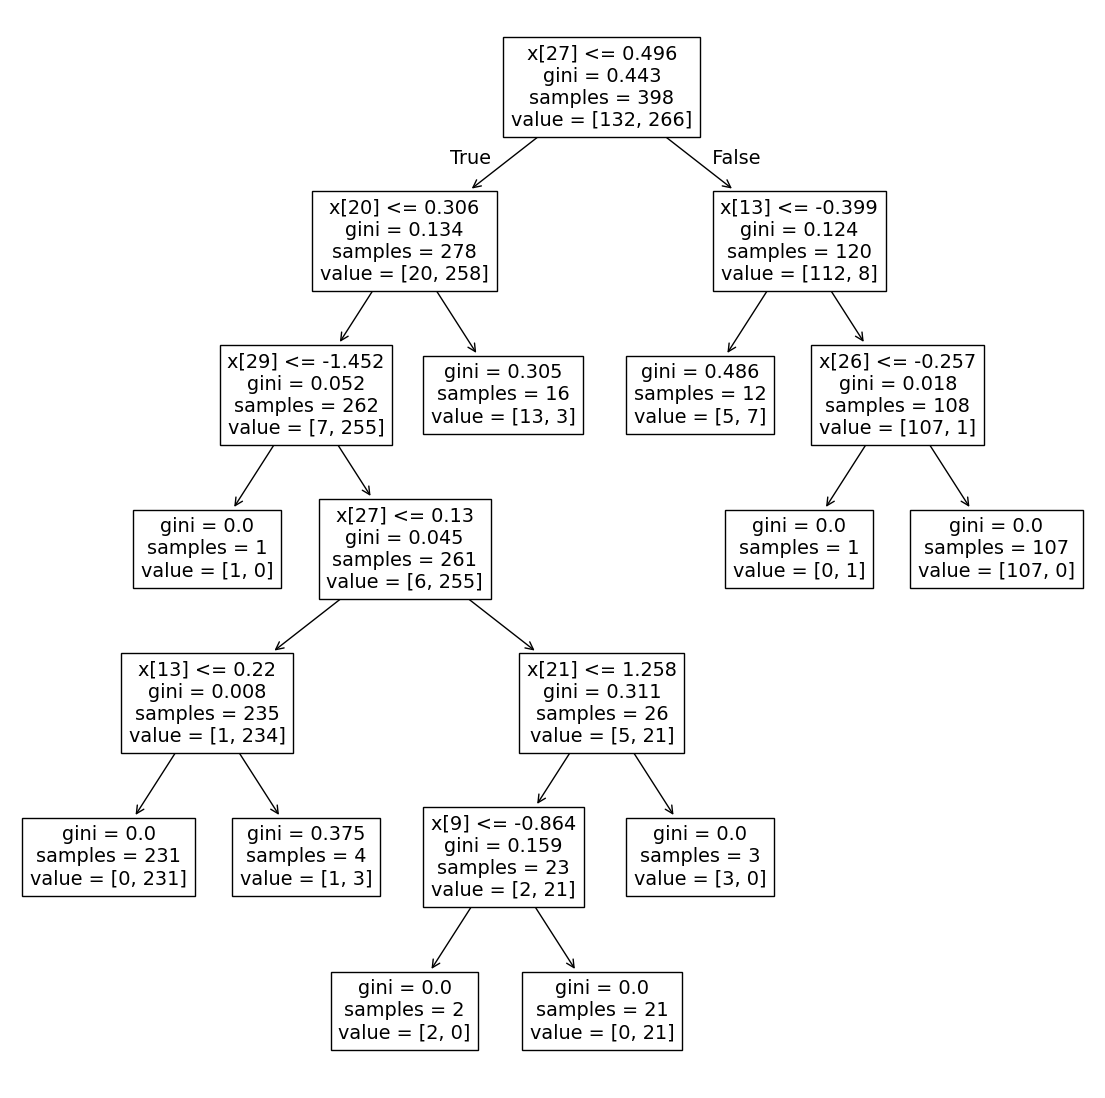

In [36]:
plt.figure(figsize=(14, 14))
print(plot_tree(pipe['model']))

In [63]:
viz_model = dtreeviz.model(pipe['model'], X_train=X_train, y_train=y_train, feature_names=X_df.columns, target_name='breast_cancer', class_names=["0", "1"])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

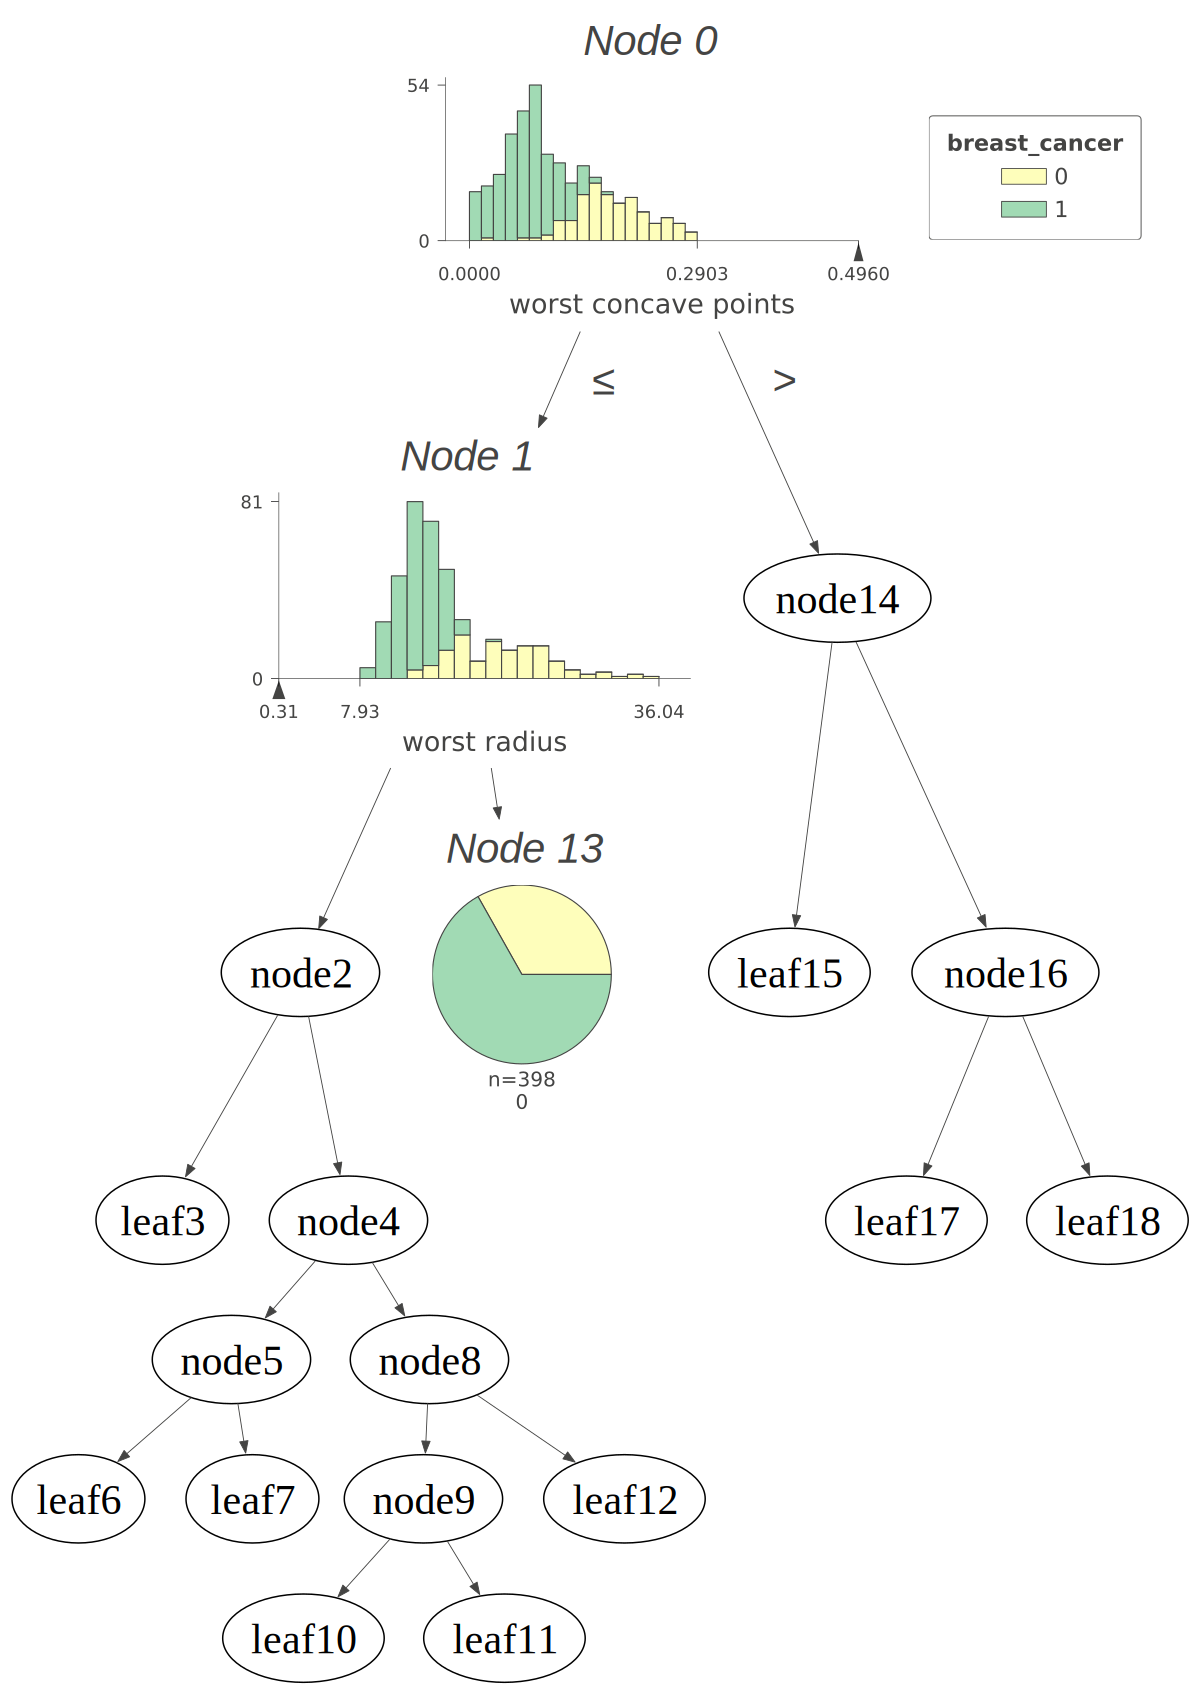

In [64]:
viz_model.view(scale=3, fontname='Arial', fancy=True, show_node_labels=True)

Hyperparam Tuning

In [67]:
high = int(X_train.shape[0] * 0.01)
if high < 2:
    high = 3
param = {
    'model__criterion' : ["gini", "entropy", "log_loss"],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [i for i in range(1, 50)],
    'model__min_samples_split': [i for i in range(2, high)]
}

In [68]:
grid = GridSearchCV(pipe, param_grid=param, cv=5, scoring='recall')

In [69]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...s_split=20))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [1, 2, ...], 'model__min_samples_split': [2], 'model__splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [70]:
print('Grid Best Score', grid.best_score_)
print('Grid Best Parameters', grid.best_params_)

Grid Best Score 0.9812019566736548
Grid Best Parameters {'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_split': 2, 'model__splitter': 'random'}


In [71]:
y_pred = grid.predict(X_test)
print("Recall of Test after GridSearchCV", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Recall of Test after GridSearchCV 0.967032967032967
              precision    recall  f1-score   support

           0       0.96      0.91      0.94        80
           1       0.93      0.97      0.95        91

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [72]:
print("Grid Cross val recall on test: ", np.mean(cross_val_score(grid, y_test.reshape(-1, 1), y_pred.reshape(-1, 1), cv=5, scoring='recall')))

Grid Cross val recall on test:  0.9263157894736842


In [73]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler_age_fare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


[Text(0.47596153846153844, 0.95, 'x[6] <= -0.14\ngini = 0.443\nsamples = 398\nvalue = [132, 266]'), Text(0.25, 0.85, 'x[22] <= -0.053\ngini = 0.082\nsamples = 233\nvalue = [10, 223]'), Text(0.3629807692307692, 0.8999999999999999, 'True  '), Text(0.15384615384615385, 0.75, 'x[12] <= 1.212\ngini = 0.019\nsamples = 206\nvalue = [2.0, 204.0]'), Text(0.07692307692307693, 0.65, 'x[13] <= -0.241\ngini = 0.01\nsamples = 204\nvalue = [1, 203]'), Text(0.038461538461538464, 0.55, 'gini = 0.0\nsamples = 182\nvalue = [0, 182]'), Text(0.11538461538461539, 0.55, 'x[10] <= 0.866\ngini = 0.087\nsamples = 22\nvalue = [1, 21]'), Text(0.07692307692307693, 0.45, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'), Text(0.15384615384615385, 0.45, 'x[14] <= 1.569\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'), Text(0.11538461538461539, 0.35, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'), Text(0.19230769230769232, 0.35, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'), Text(0.23076923076923078, 0.65, 'x[28] <= -1.518\ngini = 0

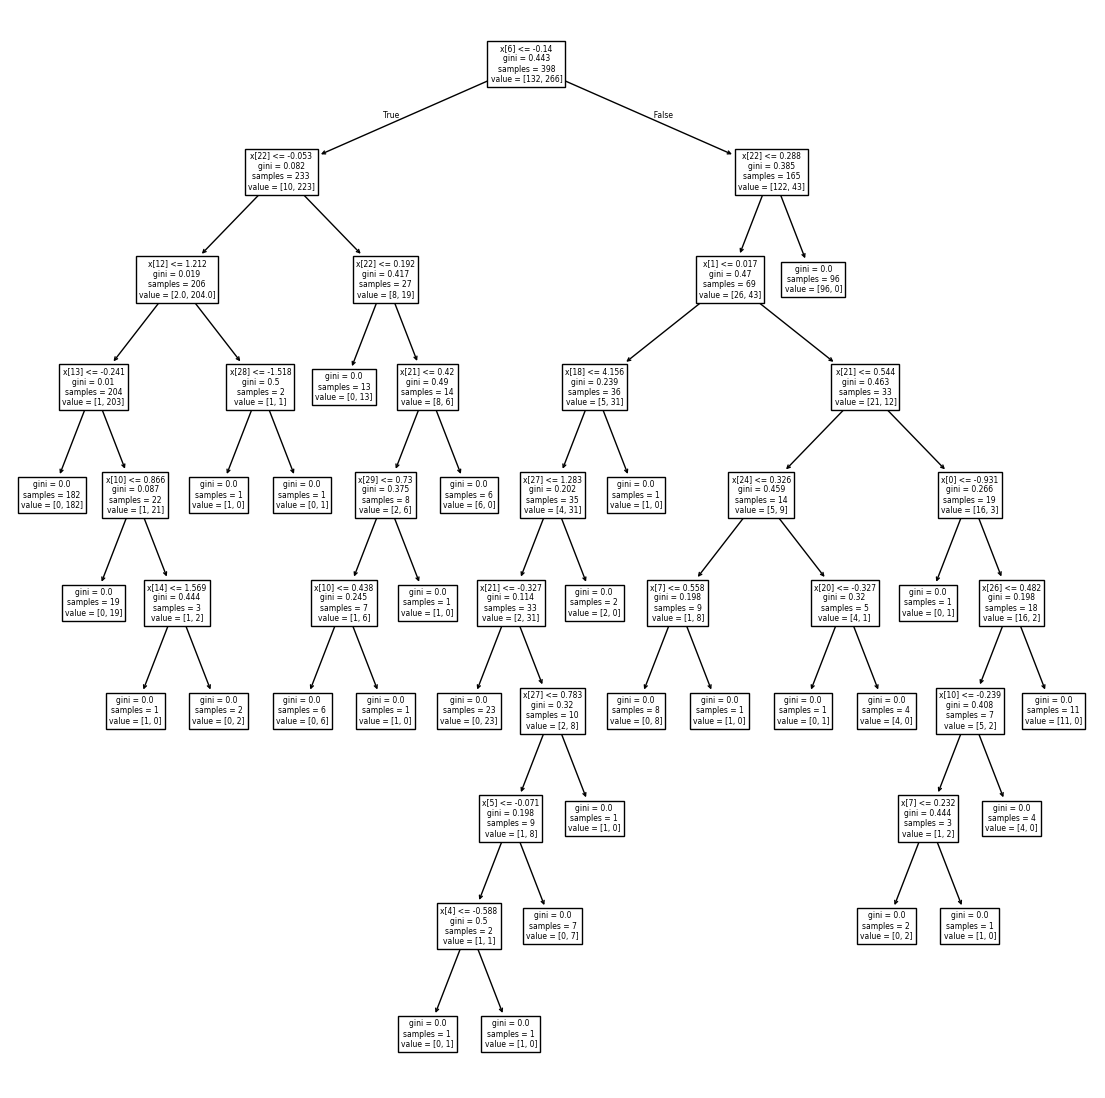

In [74]:
plt.figure(figsize=(14, 14))
print(plot_tree(grid.best_estimator_['model']))

In [75]:
viz_model = dtreeviz.model(grid.best_estimator_['model'], X_train=X_train, y_train=y_train, feature_names=X_df.columns, target_name='breast_cancer', class_names=["0", "1"])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

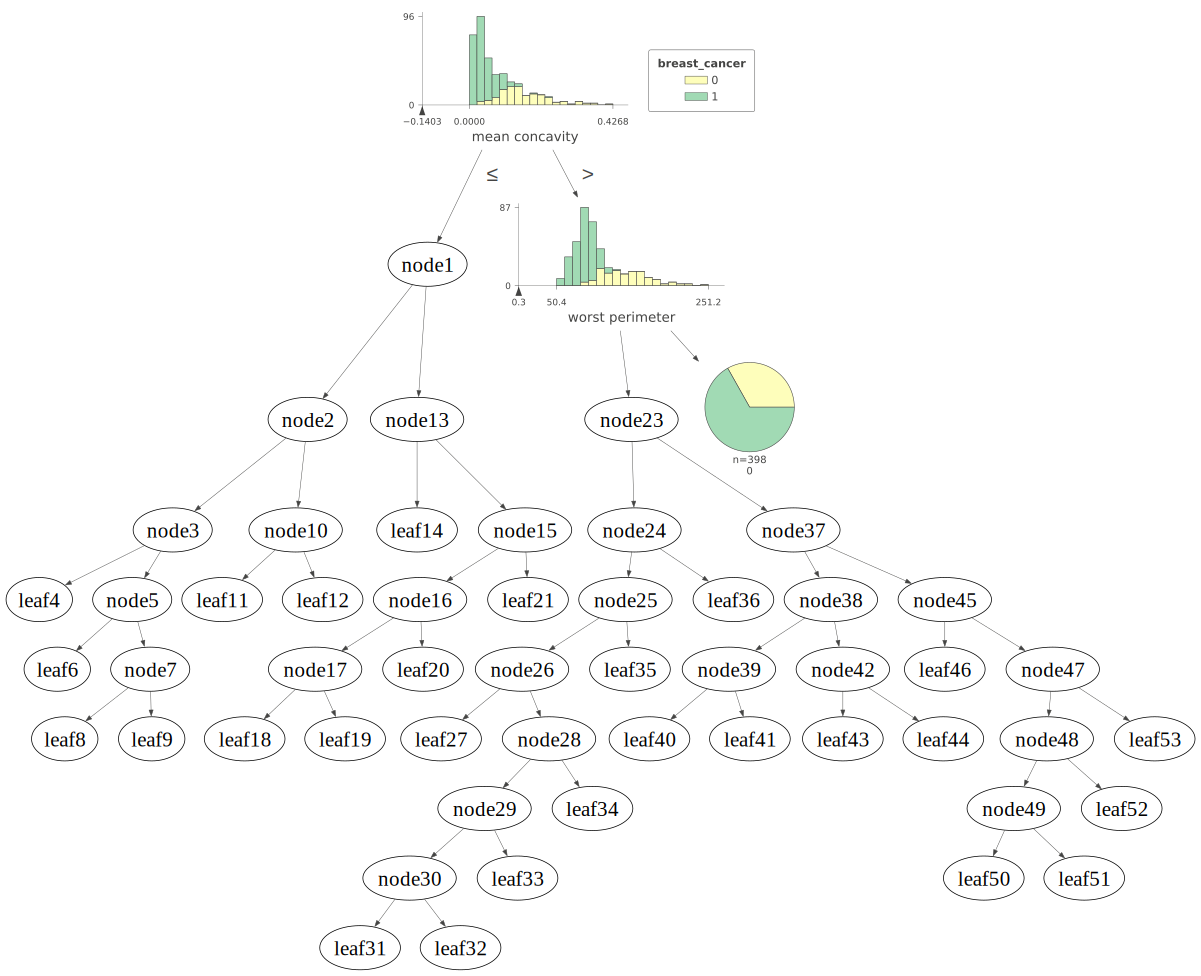

In [76]:
viz_model.view(scale=1.5, fontname='Arial')